# Low-rank RL 

This notebook is an interactive version of `experiments/run.py`. It trains an agent from following the `YAML` file in `\configs` and then runs the full low-rank analysis suite, rendering every plot inline.

See, `experiments/README.md` for the config schema and `low_rank_rl/analysis/README.md` for explaination behind the different metrics.  

## 1. Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pathlib
import sys

# walk up the tree until we find the package — that way the notebook works
# whether it's opened from the repo root or from inside experiments/
REPO_ROOT = pathlib.Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "low_rank_rl").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import yaml

from IPython.display import display, clear_output

from low_rank_rl.envs import make_env, rollout_policy, animate_rollout, plot_rollout_strip
from low_rank_rl.agents import (
    DQNAgent, QLearningAgent, SarsaAgent, MonteCarloAgent, PPOAgent,
)
from low_rank_rl.training import train
from low_rank_rl.analysis.rank import compute_rank_metrics, sample_states, canonical_subsample
from low_rank_rl.analysis.tensor import build_value_tensor, hosvd_spectra
from low_rank_rl.analysis.hankel import hankel_rank_metrics
from low_rank_rl.analysis.successor import compare_shift_rank
from low_rank_rl.visualization.training import (
    plot_episode_durations,
    plot_episode_rewards,
)
from low_rank_rl.visualization.rank_analysis import (
    plot_singular_value_spectrum,
    plot_hosvd_spectra,
    plot_rank_vs_episode,
    plot_hankel_spectrum,
    plot_hankel_spectra_over_training,
    plot_shift_comparison,
)
from low_rank_rl.visualization.value_fn import plot_value_heatmap

print(f"Repo root: {REPO_ROOT}")

Repo root: /Users/souparna/Low-Rank-RL-TL


## 2. Config

Two ways to configure an experiment:

- **(A) Load a YAML** from `experiments/configs/` — same file that `run.py` consumes.
- **(B) Override** any field on the loaded config directly in Python.

You can skip (A) entirely and build the `cfg` dict from scratch.

In [2]:
CONFIG_PATH = REPO_ROOT / "experiments" / "configs" / "acrobot_ppo.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Uncomment any of these if you just want a quick smoke test rather than a full run.
# cfg["training"]["n_episodes"] = 50
# cfg["training"]["rank_checkpoint_every"] = 10
# cfg["training"]["n_rank_samples"] = 256

cfg

{'env_id': 'Acrobot-v1',
 'agent': 'ppo',
 'training': {'n_episodes': 1000,
  'rank_checkpoint_every': 100,
  'n_rank_samples': 1024},
 'agent_kwargs': {'hidden': 128,
  'lr': 0.0003,
  'gamma': 0.99,
  'gae_lambda': 0.95,
  'clip_eps': 0.2,
  'entropy_coef': 0.01,
  'value_coef': 0.5,
  'ppo_epochs': 8,
  'mini_batch_size': 128},
 'env_kwargs': {'normalize_obs': True,
  'discretize_obs': True,
  'n_state_bins': [21, 2, 21, 2, 21, 21]},
 'analysis': {'hankel_steps': None,
  'hankel_n_rows': None,
  'value_tensor_bins': None,
  'value_tensor_dims': [0, 1, 2, 3, 4, 5, 6]},
 'output': {'save_dir': 'outputs/acrobot_ppo', 'save_agent': True}}

## 3. Environment and agent

In [3]:
def build_agent(agent_name, env, kwargs):
    obs_space = env.observation_space
    n_obs     = obs_space.shape[0]
    n_actions = env.action_space.n
    if agent_name == "dqn":
        return DQNAgent(n_obs=n_obs, n_actions=n_actions, **kwargs)
    if agent_name in ("qlearning", "q_learning"):
        return QLearningAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "sarsa":
        return SarsaAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "monte_carlo":
        return MonteCarloAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "ppo":
        return PPOAgent(n_obs=n_obs, n_actions=n_actions, **kwargs)
    raise ValueError(f"Unknown agent: {agent_name!r}")


env   = make_env(cfg["env_id"], **cfg.get("env_kwargs", {}))
agent = build_agent(cfg["agent"], env, cfg.get("agent_kwargs", {}))
print(f"Env    : {cfg['env_id']}")
print(f"Agent  : {agent}")
print(f"Episodes: {cfg['training']['n_episodes']}")

Env    : Acrobot-v1
Agent  : PPOAgent(n_obs=6, n_actions=3, device=mps)
Episodes: 1000


## 4. Training

`low_rank_rl.training.train(agent, env, cfg, on_episode=...)` auto-selects the
correct loop for the agent (step-based for DQN/Q-learning/SARSA, episode-based
for Monte Carlo, PPO with bootstrapped `last_value` on truncation).

The cell below shows:

- a **tqdm progress bar** with rolling-mean reward in the postfix;
- a **live reward-vs-episode plot** that refreshes every `REFRESH_EVERY`
  episodes via an `on_episode` callback.

The DQN loop is from  [PyTorch RL tutorial](https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html);
the PPO loop is from [OpenAI Spinning Up's PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html).

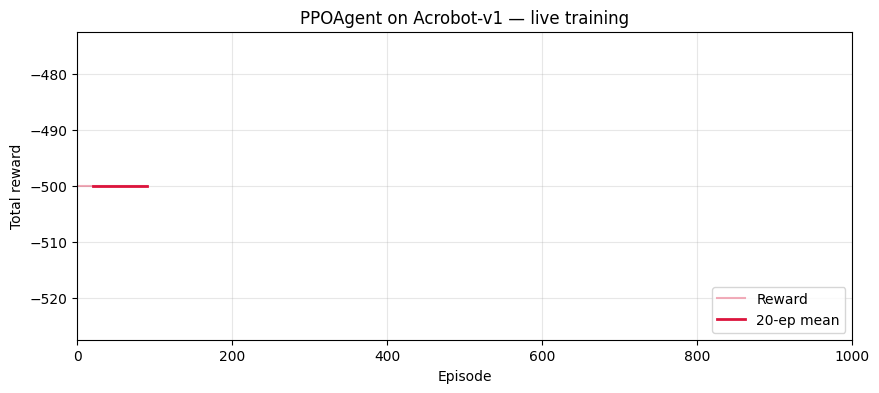

PPOAgent train:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [4]:
REFRESH_EVERY = 5  # don't redraw every episode — gets choppy and slows training down

n_ep = cfg["training"]["n_episodes"]

fig_live, ax_live  = plt.subplots(figsize=(10, 4))
line_raw,          = ax_live.plot([], [], alpha=0.35, color="crimson", label="Reward")
line_avg,          = ax_live.plot([], [], color="crimson", linewidth=2, label="20-ep mean")
ax_live.set_xlim(0, n_ep)
ax_live.set_xlabel("Episode")
ax_live.set_ylabel("Total reward")
ax_live.set_title(f"{type(agent).__name__} on {cfg['env_id']} — live training")
ax_live.grid(True, alpha=0.3)
ax_live.legend(loc="lower right")
live_handle = display(fig_live, display_id="live_reward_plot")
plt.close(fig_live)

_reward_buffer = []

def _on_episode(ep: int, duration: int, reward: float) -> None:
    _reward_buffer.append(reward)
    if ep % REFRESH_EVERY != 0 and ep != n_ep:
        return
    xs = np.arange(1, len(_reward_buffer) + 1)
    ys = np.asarray(_reward_buffer, dtype=float)
    line_raw.set_data(xs, ys)
    w = min(20, len(ys))
    if w > 1:
        avg = np.convolve(ys, np.ones(w) / w, mode="valid")
        line_avg.set_data(np.arange(w, len(ys) + 1), avg)
    ax_live.relim(); ax_live.autoscale_view(scalex=False, scaley=True)
    live_handle.update(fig_live)

log = train(agent, env, cfg, on_episode=_on_episode, progress=True)
durations, rewards, rank_history = log.durations, log.rewards, log.rank_history

print(f"\nTrained {len(durations)} episodes — last reward = {rewards[-1]:+.1f}, "
      f"best = {max(rewards):+.1f}, mean(last 20) = {np.mean(rewards[-20:]):+.1f}")

## 5. Training plots

In [ ]:
plot_episode_durations(durations, window=max(5, len(durations) // 10))
plt.show()

plot_episode_rewards(rewards, window=max(5, len(rewards) // 10))
plt.show()

In [ ]:
if rank_history:
    plot_rank_vs_episode(rank_history)
    plt.show()
else:
    print("No rank checkpoints were recorded — increase n_episodes or lower rank_checkpoint_every.")

### Hankel spectra per checkpoint

If the active config sets `analysis.hankel_sequence_types` (e.g. `["value", "q_taken"]`), `rank_history` entries carry a full Hankel `singular_values` vector for each listed scalar sequence at every checkpoint. The plot below overlays those spectra across training (colour = episode) and tracks the numerical rank over time — a fast visual read on whether the greedy-policy trajectory is getting more or less low-rank as the agent learns.


In [ ]:
hankel_seqs = cfg.get("analysis", {}).get("hankel_sequence_types") or []
if not hankel_seqs:
    print("No per-checkpoint Hankel data captured. "
          "Set analysis.hankel_sequence_types in the config (e.g. [\"value\", \"q_taken\"]) and re-train.")
else:
    for seq in hankel_seqs:
        plot_hankel_spectra_over_training(rank_history, sequence_type=seq)
        plt.show()


## 6. Q-matrix rank analysis

$Q \in \mathbb{R}^{N \times |\mathcal A|}$. When the env is discretised, `sample_states` returns the **full canonical grid** (one row per bin centre), so this is the exact tabular rank. Otherwise $N$ states are drawn under a uniform random policy.

See `low_rank_rl/analysis/README.md` for the numerical / stable / effective rank definitions.

In [ ]:
probe_states = sample_states(env, cfg["training"]["n_rank_samples"])
print(f"Probe states: {probe_states.shape[0]}")
metrics = compute_rank_metrics(agent, probe_states)
print(metrics.summary())
plot_singular_value_spectrum(metrics)
plt.show()

## 7. Value tensor (HOSVD)

Builds $\mathcal V_{i_1 \dots i_k} \approx \mathrm{mean}\{V(s) : s \in \text{bin}(i_1, \dots, i_k)\}$ and plots the singular values of each mode-$n$ unfolding.

In [ ]:
analysis_cfg = cfg.get("analysis", {})
V_tensor = build_value_tensor(
    agent, env,
    dims=analysis_cfg.get("value_tensor_dims"),
    n_bins=analysis_cfg.get("value_tensor_bins"),  # leave as None and we'll reuse the wrapper's grid if it has one
    n_samples=min(20_000, cfg["training"]["n_rank_samples"] * 50),
)
print(f"Value tensor shape: {V_tensor.shape}")

spectra = hosvd_spectra(V_tensor)
plot_hosvd_spectra(spectra)
plt.show()

## 8. Hankel analysis

Rolls out one full trajectory under the current greedy policy $\pi$ (i.e. the agent's current best estimate of the optimal policy), then builds the Hankel matrix $H_{ij} = f_{i+j}$ for a scalar sequence $f_t$ extracted from the trajectory. We look at several channels:

- `value`:   $f_t = V(s_t) = \max_a Q(s_t, a)$
- `q_taken`: $f_t = Q(s_t, a_t)$
- `policy`:  $f_t = \arg\max_a Q(s_t, a)$
- `actions`: $f_t = a_t$

`n_steps=None` runs to natural termination or `env.spec.max_episode_steps`, and `n_rows=None` picks a square Hankel (`T//2`) — the choice that maximises `min(n_rows, n_cols)` and thus the largest rank we can detect. Low Hankel rank $\leftrightarrow$ approximate finite-dimensional (Koopman-like) linear dynamics of that scalar along the trajectory.

In [ ]:
for seq_type in ("value", "q_taken"):
    hm = hankel_rank_metrics(
        agent, env,
        sequence_type=seq_type,
        n_steps=analysis_cfg.get("hankel_steps"),   # None just means "let the episode run to its natural end"
        n_rows=analysis_cfg.get("hankel_n_rows"),   # None gives a square Hankel (T // 2) — usually what you want
    )
    print(hm.summary())
    plot_hankel_spectrum(hm)
    plt.show()

## 9. Successor measure shift

Builds $\hat M^\pi$ empirically and compares it to the shifted version $\tilde M^\pi = \hat M^\pi - \mathbf 1 \hat\mu^\top$.

**Runtime**: $O(N^2 \cdot T)$, so we cap $N \le 64$. `canonical_subsample` takes a random subset of the canonical grid when discretised, or MC-samples states otherwise.

In [ ]:
N_probe = min(64, cfg["training"]["n_rank_samples"])
probe_states_small = canonical_subsample(env, N_probe)
comparison = compare_shift_rank(agent, env, probe_states_small, gamma=0.99, n_rollout_steps=200)
print(comparison.summary())
plot_shift_comparison(comparison)
plt.show()

## 10. Value heatmap

2-D slice of $V(s) = \max_a Q(s, a)$. For >2-D observations, all dimensions except the two on the axes are pinned at their mid-range. Tweak `dims` / `fixed_values` to explore other slices.

In [ ]:
plot_value_heatmap(agent, env, dims=(0,1), n_bins=40, title="w2 (angular vel vs Cos Theeta1" )
plt.show()

## 11. View the learnt policy

Roll out the trained agent **greedily** on a fresh env (built with `render_mode="rgb_array"` so we get back NumPy frames), then either play it inline as an animation or look at a static strip of evenly-sampled frames.

The agent's `act(..., training=False)` path is used, so the policy is deterministic (argmax of $Q$ for value-based agents, argmax of action probs for PPO).


In [ ]:
rollout = rollout_policy(
    agent,
    cfg["env_id"],
    env_kwargs=cfg.get("env_kwargs"),
    max_steps=500,
    seed=0,
)
print(f"steps={rollout.n_steps}  total_reward={rollout.total_reward:+.2f}  "
      f"terminated={rollout.terminated}  truncated={rollout.truncated}")
print(f"frames captured: {len(rollout.frames)}")


Inline animation (uses `matplotlib.animation` -> JS HTML — works in Jupyter / VSCode notebooks):


In [ ]:
from IPython.display import HTML

ani = animate_rollout(
    rollout.frames,
    interval=40,
    title=f"{type(agent).__name__} on {cfg['env_id']} (R={rollout.total_reward:+.2f})",
)
HTML(ani.to_jshtml())


In [ ]:
from IPython.display import HTML

ani = animate_rollout(
    rollout.frames,
    interval=40,
    title=f"{type(agent).__name__} on {cfg['env_id']} (R={rollout.total_reward:+.2f})",
)
HTML(ani.to_jshtml())


In [ ]:
plot_rollout_strip(rollout.frames, n_cols=8,
                   title=f"{type(agent).__name__} greedy rollout — {cfg['env_id']}")
plt.show()


Optionally save the rollout as a GIF:


In [ ]:
SAVE_GIF = True
if SAVE_GIF:
    from low_rank_rl.envs import save_rollout_gif
    out_dir = REPO_ROOT / cfg["output"]["save_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    gif_path = out_dir / "policy_rollout.gif"
    save_rollout_gif(rollout.frames, str(gif_path), fps=25)
    print(f"Saved {gif_path}")


## 12. (Optional) save agent and close env

In [ ]:
SAVE = True  # turn this off if you're just poking around and don't want files on disk
if SAVE:
    out_dir = REPO_ROOT / cfg["output"]["save_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    agent.save(out_dir / "agent.pt")
    print(f"Saved to {out_dir}/agent.pt")

env.close()